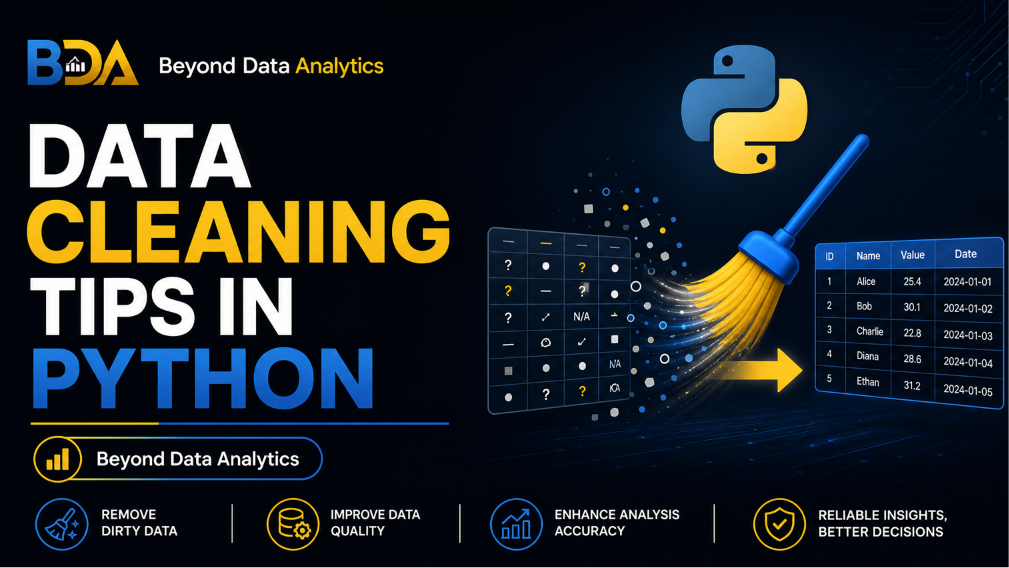

## **Data Cleaning and Preprocessing Tips**

#### **Step 1: Install Data Profiling Library**

In [1]:
#!pip install fg-data-profiling
#!pip install ydata-profiling

#### **Step 2: Load the Required Library**

In [1]:
import pandas as pd
import webbrowser
import numpy as np
#import data_profiling
#from data_profiling import ProfileReport
#from fg_data_profiling import ProfileReport

#### **Step 3- Load and Look at the Data Profile**

In [2]:
df = pd.read_csv("Business_Data_Quality_Issues.csv")
df.head()

,OrderID,CustomerID,FirstName,LastName,Gender,Age,Region,ProductCategory,Quantity,UnitPrice,...,SalesRep,PaymentMethod,CustomerSegment,City,OrderDate,Email,Phone,Rating,Comments,Revenue
0,ORD000001,CUST46472,Kelly,Baker,Male,53,South,Sports,10,2775.16,...,Nancy,Bank Transfer,Wholesale,Nairobi,2025-05-24,vincent2294@gmail.com,0713301123,4,Late delivery,25253.96
1,ORD000002,CUST28725,Adam,Jordan,NaN,39,South,Sports,6,688.75,...,Tabitha,Cash,NaN,NaN,2024-09-18,marilyn547@gmail.com,0774478500,5,Late delivery,2810.10
2,ORD000003,CUST11646,Paul,Adams,Female,43,West,Health & Beauty,17,2327.62,...,Ian,Mobile Money,SME,Malindi,2023-07-07,NaN,0710826636,3,Highly recommended,24928.81
3,ORD000004,CUST66427,Chris,Fox,Male,75,East,Furniture,5,1477.19,...,Brian,Mobile Money,Wholesale,Naivasha,2024-02-11,charlotte217@gmail.com,0761837969,5,Product damaged,5391.74
4,ORD000005,CUST55342,Nancy,Njoroge,Male,71,East,NaN,-16,253.64,...,Steve,Bank Transfer,SME,embu,2024-02-15,logan1615@gmail.com,0752633078,4,Average experience,-3003.10


#### **Step 4-Profile the Data to Identify Data Quality Issues**

In [3]:
#profile = ProfileReport(df, title="Profiling Report", explorative=True)
#profile.to_file('report.html')
#webbrowser.open("report.html")

#### **Step 5: Exploratory Data Analysis**
##### **Check the Shape of the Data**

In [4]:
df.shape

(60500, 21)

##### **Check the Data Types**

In [5]:
df.dtypes

OrderID             object
CustomerID          object
FirstName           object
LastName            object
Gender              object
Age                  int64
Region              object
ProductCategory     object
Quantity             int64
UnitPrice          float64
Discount           float64
SalesRep            object
PaymentMethod       object
CustomerSegment     object
City                object
OrderDate           object
Email               object
Phone               object
Rating               int64
Comments            object
Revenue            float64
dtype: object

##### **Check the Number of Missing Values**

In [6]:
df.isnull().sum()

OrderID               0
CustomerID            0
FirstName          2874
LastName           2884
Gender             3010
Age                   0
Region             3031
ProductCategory    3032
Quantity              0
UnitPrice             0
Discount              0
SalesRep           3021
PaymentMethod      3015
CustomerSegment    3022
City               3030
OrderDate             0
Email              3012
Phone              3098
Rating                0
Comments           3003
Revenue               0
dtype: int64

##### **Chec the Percentages of Missing Values**

In [7]:
df.isnull().mean()*100

OrderID            0.000000
CustomerID         0.000000
FirstName          4.750413
LastName           4.766942
Gender             4.975207
Age                0.000000
Region             5.009917
ProductCategory    5.011570
Quantity           0.000000
UnitPrice          0.000000
Discount           0.000000
SalesRep           4.993388
PaymentMethod      4.983471
CustomerSegment    4.995041
City               5.008264
OrderDate          0.000000
Email              4.978512
Phone              5.120661
Rating             0.000000
Comments           4.963636
Revenue            0.000000
dtype: float64

#### **Step 6: Standardize the Column Names**
In this step, we standardizes the column names of a pandas DataFrame to make them cleaner, more consistent, and easier to use during data analysis. We remove any unnecessary spaces at the beginning or end of the column names, converts all text to lowercase, replaces spaces with underscores, and removes opening and closing parentheses. These transformations help create uniform column names that are easier to reference in Python code and reduce the likelihood of errors caused by inconsistent naming.

Standardizing column names is a common data cleaning practice because it improves code readability and compatibility with data analysis libraries. Clean, consistent column names make tasks such as filtering, selecting variables, merging datasets, and building machine learning models more straightforward, while also reducing the need to remember or type complex names containing spaces or special characters.


In [8]:
df.columns = (
    df.columns.
    str.strip().
    #str.lower().
    str.replace(' ', '_').
    str.replace('(', '').
    str.replace(')', '')
)
df.head()

,OrderID,CustomerID,FirstName,LastName,Gender,Age,Region,ProductCategory,Quantity,UnitPrice,...,SalesRep,PaymentMethod,CustomerSegment,City,OrderDate,Email,Phone,Rating,Comments,Revenue
0,ORD000001,CUST46472,Kelly,Baker,Male,53,South,Sports,10,2775.16,...,Nancy,Bank Transfer,Wholesale,Nairobi,2025-05-24,vincent2294@gmail.com,0713301123,4,Late delivery,25253.96
1,ORD000002,CUST28725,Adam,Jordan,NaN,39,South,Sports,6,688.75,...,Tabitha,Cash,NaN,NaN,2024-09-18,marilyn547@gmail.com,0774478500,5,Late delivery,2810.10
2,ORD000003,CUST11646,Paul,Adams,Female,43,West,Health & Beauty,17,2327.62,...,Ian,Mobile Money,SME,Malindi,2023-07-07,NaN,0710826636,3,Highly recommended,24928.81
3,ORD000004,CUST66427,Chris,Fox,Male,75,East,Furniture,5,1477.19,...,Brian,Mobile Money,Wholesale,Naivasha,2024-02-11,charlotte217@gmail.com,0761837969,5,Product damaged,5391.74
4,ORD000005,CUST55342,Nancy,Njoroge,Male,71,East,NaN,-16,253.64,...,Steve,Bank Transfer,SME,embu,2024-02-15,logan1615@gmail.com,0752633078,4,Average experience,-3003.10


##### **Print the Percentage for Missing Values**

In [9]:
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

Phone              5.120661
ProductCategory    5.011570
Region             5.009917
City               5.008264
CustomerSegment    4.995041
SalesRep           4.993388
PaymentMethod      4.983471
Email              4.978512
Gender             4.975207
Comments           4.963636
LastName           4.766942
FirstName          4.750413
dtype: float64

#### **Step 7: Handle Duplicates, Missing Values, and Messy Columns**
##### **Check Duplicate Rows**

In [10]:
dupes = df.duplicated()
dupes.sum()

np.int64(442)

##### **Print the Duplicated Rows**

In [11]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,OrderID,CustomerID,FirstName,LastName,Gender,Age,Region,ProductCategory,Quantity,UnitPrice,...,SalesRep,PaymentMethod,CustomerSegment,City,OrderDate,Email,Phone,Rating,Comments,Revenue
148,ORD000149,CUST94771,Pamela,Burke,Male,24,East,Automotive,6,2139.59,...,Hilda,Mobile Money,Wholesale,Nakuru,2024-08-29,danielle578@gmail.com,0770161787,3,Average experience,11810.54
60465,ORD000149,CUST94771,Pamela,Burke,Male,24,East,Automotive,6,2139.59,...,Hilda,Mobile Money,Wholesale,Nakuru,2024-08-29,danielle578@gmail.com,0770161787,3,Average experience,11810.54
388,ORD000389,CUST23228,Albert,NaN,Female,59,Central,NaN,13,2673.31,...,Oscar,Cash,Wholesale,Kisumu,2023-07-04,shirley2362@gmail.com,0723743233,2,Fast shipping,28149.95
60305,ORD000389,CUST23228,Albert,NaN,Female,59,Central,NaN,13,2673.31,...,Oscar,Cash,Wholesale,Kisumu,2023-07-04,shirley2362@gmail.com,0723743233,2,Fast shipping,28149.95
453,ORD000454,CUST66109,Alan,Fleming,Female,19,West,Health & Beauty,7,2626.28,...,Ian,Mobile Money,Wholesale,NaN,2024-02-06,ashley8369@gmail.com,0725012879,3,Fast shipping,12133.41
60028,ORD000454,CUST66109,Alan,Fleming,Female,19,West,Health & Beauty,7,2626.28,...,Ian,Mobile Money,Wholesale,NaN,2024-02-06,ashley8369@gmail.com,0725012879,3,Fast shipping,12133.41
556,ORD000557,CUST48671,Alicia,Pearson,Male,45,North,NaN,7,474.09,...,Valerie,Debit Card,Wholesale,Malindi,2024-01-24,aaron3115@gmail.com,NaN,5,Late delivery,2688.09
60472,ORD000557,CUST48671,Alicia,Pearson,Male,45,North,NaN,7,474.09,...,Valerie,Debit Card,Wholesale,Malindi,2024-01-24,aaron3115@gmail.com,NaN,5,Late delivery,2688.09
679,ORD000680,CUST39909,Ethan,Jackson,Male,60,West,NaN,20,2698.12,...,Oliver,Bank Transfer,Government,Nyeri,2024-10-07,deborah3330@gmail.com,0792774249,3,Average experience,39932.18
60136,ORD000680,CUST39909,Ethan,Jackson,Male,60,West,NaN,20,2698.12,...,Oliver,Bank Transfer,Government,Nyeri,2024-10-07,deborah3330@gmail.com,0792774249,3,Average experience,39932.18


##### **Drop the Duplicated Rows**

In [12]:
df.drop_duplicates(keep='first', inplace=True)
df.shape

(60058, 21)

##### **Replace the Missing Value for Categorical / Object Columns with 'Unknown'**

In [13]:
df = df.copy()

##### **Replace missing values in numeric columns with the median**

In [14]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

##### **Replace missing values in categorical/object columns with "Unknown"**

In [15]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

##### **Display remaining missing values**

In [16]:
print(df.isnull().sum())

OrderID            0
CustomerID         0
FirstName          0
LastName           0
Gender             0
Age                0
Region             0
ProductCategory    0
Quantity           0
UnitPrice          0
Discount           0
SalesRep           0
PaymentMethod      0
CustomerSegment    0
City               0
OrderDate          0
Email              0
Phone              0
Rating             0
Comments           0
Revenue            0
dtype: int64


##### **View the Data After Handling Missing Values**

In [17]:
df.head()

,OrderID,CustomerID,FirstName,LastName,Gender,Age,Region,ProductCategory,Quantity,UnitPrice,...,SalesRep,PaymentMethod,CustomerSegment,City,OrderDate,Email,Phone,Rating,Comments,Revenue
0,ORD000001,CUST46472,Kelly,Baker,Male,53,South,Sports,10,2775.16,...,Nancy,Bank Transfer,Wholesale,Nairobi,2025-05-24,vincent2294@gmail.com,0713301123,4,Late delivery,25253.96
1,ORD000002,CUST28725,Adam,Jordan,Unknown,39,South,Sports,6,688.75,...,Tabitha,Cash,Unknown,Unknown,2024-09-18,marilyn547@gmail.com,0774478500,5,Late delivery,2810.10
2,ORD000003,CUST11646,Paul,Adams,Female,43,West,Health & Beauty,17,2327.62,...,Ian,Mobile Money,SME,Malindi,2023-07-07,Unknown,0710826636,3,Highly recommended,24928.81
3,ORD000004,CUST66427,Chris,Fox,Male,75,East,Furniture,5,1477.19,...,Brian,Mobile Money,Wholesale,Naivasha,2024-02-11,charlotte217@gmail.com,0761837969,5,Product damaged,5391.74
4,ORD000005,CUST55342,Nancy,Njoroge,Male,71,East,Unknown,-16,253.64,...,Steve,Bank Transfer,SME,embu,2024-02-15,logan1615@gmail.com,0752633078,4,Average experience,-3003.10


#### **Standardize the Values for Categorical and Object Variables**

##### **Gender**

In [18]:
df['Gender'].value_counts()

Gender
Male       29600
Female     27167
Unknown     3052
FEMALE        70
F             58
M             57
male          54
Name: count, dtype: int64

##### **Standardize Gender values**

In [19]:
df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "male": "Male",
    "F": "Female",
    "FEMALE": "Female"
})

# Check the results
print(df["Gender"].value_counts())

Gender
Male       29711
Female     27295
Unknown     3052
Name: count, dtype: int64


##### **Region**

In [20]:
df['Region'].value_counts() 

Region
North      10761
West       10675
East       10657
Central    10605
South      10546
Unknown     3003
SOUTH        780
WEST         776
EAST         766
NORTH        766
CENTRAL      723
Name: count, dtype: int64

##### **Standaride Region Values**

In [21]:
# Standardize Region values
df["Region"] = df["Region"].replace({
    "NORTH": "North",
    "SOUTH": "South",
    "EAST": "East",
    "WEST": "West",
    "CENTRAL": "Central"
})

# Check the results
print(df["Region"].value_counts())

Region
North      11527
West       11451
East       11423
Central    11328
South      11326
Unknown     3003
Name: count, dtype: int64


##### **Product Category**

In [22]:
df['ProductCategory'].value_counts()

ProductCategory
Furniture              5756
Automotive             5735
Clothing               5718
Electronics            5694
Sports                 5678
Books                  5643
Health & Beauty        5539
Food & Beverage        5485
Office Supplies        5474
Home Appliances        5358
Unknown                3002
Food   &   Beverage     255
Office   Supplies       247
Health   &   Beauty     240
Home   Appliances       234
Name: count, dtype: int64

In [23]:
# Remove leading/trailing spaces and replace multiple spaces with a single space
df["ProductCategory"] = (
    df["ProductCategory"]
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

# Verify
print(df["ProductCategory"].value_counts())

ProductCategory
Health & Beauty    5779
Furniture          5756
Food & Beverage    5740
Automotive         5735
Office Supplies    5721
Clothing           5718
Electronics        5694
Sports             5678
Books              5643
Home Appliances    5592
Unknown            3002
Name: count, dtype: int64


##### **Check column names in the df**

In [24]:
column_names = df.columns.tolist()
column_names

['OrderID',
 'CustomerID',
 'FirstName',
 'LastName',
 'Gender',
 'Age',
 'Region',
 'ProductCategory',
 'Quantity',
 'UnitPrice',
 'Discount',
 'SalesRep',
 'PaymentMethod',
 'CustomerSegment',
 'City',
 'OrderDate',
 'Email',
 'Phone',
 'Rating',
 'Comments',
 'Revenue']

#### **Continous Variables**

In [25]:
# Comprehensive summary statistics
summary = df[['Quantity', 'UnitPrice', 'Discount', 'Rating', 'Revenue']].agg([
    'count',
    'mean',
    'median',
    'std',
    'var',
    'min',
    'max',
    'skew',
    'kurt'
]).T

summary

,count,mean,median,std,var,min,max,skew,kurt
Quantity,60058.0,10.439142,10.00,5.939292,3.527519e+01,-20.00,20.0,-0.189866,-0.449897
UnitPrice,60058.0,1882.670854,1492.67,9019.433927,8.135019e+07,0.00,299599.0,25.051898,666.666497
Discount,60058.0,0.204087,0.20,0.137420,1.888426e-02,0.00,1.5,2.727144,24.239737
Rating,60058.0,3.011522,3.00,1.440207,2.074197e+00,-1.00,10.0,0.081259,-0.783252
Revenue,60058.0,15686.317883,9261.98,86082.003936,7.410111e+09,-43496.17,5207464.4,31.822079,1177.370220


In [26]:
# Replace negative quantities with NaN
df.loc[df["Quantity"] < 0, "Quantity"] = np.nan

# Fill missing values with the median
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

# Verify
print(df["Quantity"].value_counts().sort_index())

Quantity
1.0     2946
2.0     3019
3.0     3000
4.0     2945
5.0     2970
6.0     3021
7.0     3049
8.0     2977
9.0     2977
10.0    2944
11.0    3115
12.0    2964
13.0    3015
14.0    2953
15.0    3024
16.0    3005
17.0    3003
18.0    3105
19.0    2994
20.0    3032
Name: count, dtype: int64


##### **Sales Representative**

In [27]:
df['SalesRep'].value_counts().head(10)

SalesRep
Unknown    3001
Lilian     1225
Zack       1206
George     1191
Samuel     1188
Henry      1186
Abel       1173
Quincy     1172
Walter     1171
Oliver     1169
Name: count, dtype: int64

#### **Write the Sales Representative Names in Proper Format**

In [28]:
# Standardize SalesRep names
df["SalesRep"] = df["SalesRep"].str.strip().str.title()

# Display the top 10 most frequent Sales Representatives
df["SalesRep"].value_counts().head(10)

SalesRep
Unknown    3001
Lilian     1225
Zack       1206
George     1191
Samuel     1188
Henry      1186
Abel       1173
Quincy     1172
Walter     1171
Oliver     1169
Name: count, dtype: int64

##### **Payment Method**

In [29]:
df['PaymentMethod'].value_counts()

PaymentMethod
Mobile Money     11404
Cash             11396
Bank Transfer    11368
Debit Card       11339
Credit Card      11309
Unknown           3080
Crypto              86
Cheque              76
Name: count, dtype: int64

#### **Customer Segment**

In [30]:
df['CustomerSegment'].value_counts()

CustomerSegment
Government    11568
Wholesale     11467
Corporate     11456
SME           11289
Retail        11277
Unknown        3001
Name: count, dtype: int64

#### **The City**

In [31]:
df['City'].value_counts()

City
Machakos    3683
Embu        3627
Kisumu      3622
Kitale      3617
Malindi     3606
Thika       3557
Nakuru      3556
Kericho     3531
Kisii       3528
Naivasha    3525
Mombasa     3515
Nyeri       3508
Meru        3475
Eldoret     3463
Nairobi     3448
Unknown     3002
meru         269
kericho      268
nakuru       267
thika        266
kisumu       265
malindi      261
embu         259
kitale       256
nyeri        253
eldoret      252
kisii        248
naivasha     248
nairobi      238
mombasa      233
machakos     212
Name: count, dtype: int64

In [32]:
# Standardize City names
df["City"] = df["City"].str.strip().str.title()

# Display the top 10 most frequent Cities
df["City"].value_counts()

City
Machakos    3895
Kisumu      3887
Embu        3886
Kitale      3873
Malindi     3867
Nakuru      3823
Thika       3823
Kericho     3799
Kisii       3776
Naivasha    3773
Nyeri       3761
Mombasa     3748
Meru        3744
Eldoret     3715
Nairobi     3686
Unknown     3002
Name: count, dtype: int64

#### **Order Date**

In [33]:
# Convert OrderDate to datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60058 entries, 0 to 60490
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          60058 non-null  object        
 1   CustomerID       60058 non-null  object        
 2   FirstName        60058 non-null  object        
 3   LastName         60058 non-null  object        
 4   Gender           60058 non-null  object        
 5   Age              60058 non-null  int64         
 6   Region           60058 non-null  object        
 7   ProductCategory  60058 non-null  object        
 8   Quantity         60058 non-null  float64       
 9   UnitPrice        60058 non-null  float64       
 10  Discount         60058 non-null  float64       
 11  SalesRep         60058 non-null  object        
 12  PaymentMethod    60058 non-null  object        
 13  CustomerSegment  60058 non-null  object        
 14  City             60058 non-null  object    

In [34]:
df.head()

,OrderID,CustomerID,FirstName,LastName,Gender,Age,Region,ProductCategory,Quantity,UnitPrice,...,SalesRep,PaymentMethod,CustomerSegment,City,OrderDate,Email,Phone,Rating,Comments,Revenue
0,ORD000001,CUST46472,Kelly,Baker,Male,53,South,Sports,10.0,2775.16,...,Nancy,Bank Transfer,Wholesale,Nairobi,2025-05-24,vincent2294@gmail.com,0713301123,4,Late delivery,25253.96
1,ORD000002,CUST28725,Adam,Jordan,Unknown,39,South,Sports,6.0,688.75,...,Tabitha,Cash,Unknown,Unknown,2024-09-18,marilyn547@gmail.com,0774478500,5,Late delivery,2810.10
2,ORD000003,CUST11646,Paul,Adams,Female,43,West,Health & Beauty,17.0,2327.62,...,Ian,Mobile Money,SME,Malindi,2023-07-07,Unknown,0710826636,3,Highly recommended,24928.81
3,ORD000004,CUST66427,Chris,Fox,Male,75,East,Furniture,5.0,1477.19,...,Brian,Mobile Money,Wholesale,Naivasha,2024-02-11,charlotte217@gmail.com,0761837969,5,Product damaged,5391.74
4,ORD000005,CUST55342,Nancy,Njoroge,Male,71,East,Unknown,11.0,253.64,...,Steve,Bank Transfer,SME,Embu,2024-02-15,logan1615@gmail.com,0752633078,4,Average experience,-3003.10


#### **Rating and Revenue**

In [35]:
# Replace negative ratings with the median rating
df.loc[df["Rating"] < 0, "Rating"] = np.nan
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

In [36]:
# Replace negative revenue with the median revenue
df.loc[df["Revenue"] < 0, "Revenue"] = np.nan
df["Revenue"] = df["Revenue"].fillna(df["Revenue"].median())

In [37]:
# Comprehensive summary statistics
summary = df[['Quantity', 'UnitPrice', 'Discount', 'Rating', 'Revenue']].agg([
    'count',
    'mean',
    'median',
    'std',
    'var',
    'min',
    'max',
    'skew',
    'kurt'
]).T

summary

,count,mean,median,std,var,min,max,skew,kurt
Quantity,60058.0,10.529971,11.00,5.767328,3.326208e+01,1.0,20.0,-0.005074,-1.207190
UnitPrice,60058.0,1882.670854,1492.67,9019.433927,8.135019e+07,0.0,299599.0,25.051898,666.666497
Discount,60058.0,0.204087,0.20,0.137420,1.888426e-02,0.0,1.5,2.727144,24.239737
Rating,60058.0,3.015385,3.00,1.434796,2.058641e+00,0.0,10.0,0.095212,-0.809709
Revenue,60058.0,15834.660818,9377.60,86050.235470,7.404643e+09,0.0,5207464.4,31.852459,1178.894483


#### **Run the Data Profiling using the Cleaned Data**

In [38]:
#profile = ProfileReport(df, title="Profiling Report", explorative=True)
#profile.to_file('report2.html')
#webbrowser.open("report2.html")

## **DATA CLEANING TIPS**

#### **Load the Required Libraries**

In [39]:
import pandas as pd
import webbrowser
import numpy as np
#import data_profiling
#from data_profiling import ProfileReport

#### **Load the Required Data**

In [41]:
df = pd.read_csv("Messy_data.csv")
df.head(20)

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,Bonus_Target,Actual_Revenue_Generated,Project_Budget,Actual_Expenses,Credit_Score_Internal,Performance_Rating_Code,Status_Flag,Region_Code
0,TXN-000917,Linda Garcia,EMP-14813-ACC,FIN,Beta; Alpha; Epsilon,2021-12-05,2016-08-19,2016-09-18,2016-09-29,84038.81,10880.32,97199.43,42852.83,26350.08,805,4,Active,LATAM
1,TXN-006323,\tMary Brown,EMP-71877-MGT,OPS,Beta,2016-04-26,2022-07-29,2022-09-04,2022-08-21,65907.45,6063.90,103847.31,62809.78,38346.97,345,5,\tActive\t,NaN
2,TXN-006112,John Brown,EMP-56473-FIN,OPS,Zeta,2015-11-17,2018-05-16,2018-07-12,2018-06-21,70372.88,12538.79,180023.15,27815.16,80632.87,786,5,Active,NaN
3,TXN-005278,Michael Davis,EMP-66066-ACC,HR,Zeta,2016-01-22,2022-04-18,2022-05-24,2022-06-09,73693.67,14329.71,126880.20,31889.55,32164.00,386,5,Pending,NaN
4,TXN-000118,Robert Miller,EMP-52875-OPS,HR,Epsilon,2021-01-22,2021-01-31,2021-04-12,2021-04-26,78195.14,5482.09,138025.02,13755.36,57233.05,622,5,Active\t,NaN
5,TXN-001905,Michael Miller,EMP-59406-OPS,HR,Alpha,2016-03-07,2016-07-04,2016-09-09,2016-07-20,78858.47,11923.11,170732.64,12465.50,41537.21,759,4,\tActive,LATAM
6,TXN-004041,Jennifer Garcia,EMP-51756-HR,FIN,Epsilon; Zeta; Delta,2017-09-30,2022-04-28,2022-06-19,NaN,65532.15,10903.88,187556.84,77520.99,5878.07,815,3,\tActive\t,APAC
7,TXN-005049,Patricia Davis \r\t\r\r\n\r\n\t\r\...,EMP-68603-HR,OPS,Zeta,2015-05-25,2019-01-01,2019-03-25,2019-03-04,79299.16,11349.94,100368.95,32260.24,57091.59,845,2,\tActive,NaN
8,TXN-003157,John Johnson \r\t\r\r\n\r\n\t\r\n...,EMP-93941-ACC,HR,Alpha,2020-06-06,2026-02-19,2026-04-08,2026-04-11,82513.47,13292.10,89537.91,71583.64,79936.78,707,2,On Leave,NaN
9,TXN-004032,\tMary Jones,EMP-19791-ACC,MGT,Alpha,2024-09-23,2019-12-04,2020-02-28,2020-01-12,69078.72,7752.07,178117.43,59503.02,75167.73,327,5,Pending \r\r\r\n\t\r\r\n   \...,APAC


#### **Conduct Data Profiling**

In [43]:
#profile = ProfileReport(df, title="Profiling Report", explorative=True)
#profile.to_file('report2.html')
#webbrowser.open("report2.html")

#### **Clean the Column Employee_Full_Name to Removee Non-Printable Character, Trim and Proper the Column**

In [44]:
import re
# Clean, Trim, and Proper Case
df["Employee_Full_Name"] = (
    df["Employee_Full_Name"]
    .str.replace(r"[^\x20-\x7E]", "", regex=True)  # Remove non-printable characters (CLEAN)
    .str.strip()                                   # Remove leading/trailing spaces (TRIM)
    .str.replace(r"\s+", " ", regex=True)          # Replace multiple spaces with a single space
    .str.title()                                   # Convert to Proper Case (PROPER)
)

In [45]:
df.head()

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,Bonus_Target,Actual_Revenue_Generated,Project_Budget,Actual_Expenses,Credit_Score_Internal,Performance_Rating_Code,Status_Flag,Region_Code
0,TXN-000917,Linda Garcia,EMP-14813-ACC,FIN,Beta; Alpha; Epsilon,2021-12-05,2016-08-19,2016-09-18,2016-09-29,84038.81,10880.32,97199.43,42852.83,26350.08,805,4,Active,LATAM
1,TXN-006323,Mary Brown,EMP-71877-MGT,OPS,Beta,2016-04-26,2022-07-29,2022-09-04,2022-08-21,65907.45,6063.90,103847.31,62809.78,38346.97,345,5,\tActive\t,NaN
2,TXN-006112,John Brown,EMP-56473-FIN,OPS,Zeta,2015-11-17,2018-05-16,2018-07-12,2018-06-21,70372.88,12538.79,180023.15,27815.16,80632.87,786,5,Active,NaN
3,TXN-005278,Michael Davis,EMP-66066-ACC,HR,Zeta,2016-01-22,2022-04-18,2022-05-24,2022-06-09,73693.67,14329.71,126880.20,31889.55,32164.00,386,5,Pending,NaN
4,TXN-000118,Robert Miller,EMP-52875-OPS,HR,Epsilon,2021-01-22,2021-01-31,2021-04-12,2021-04-26,78195.14,5482.09,138025.02,13755.36,57233.05,622,5,Active\t,NaN


#### **Find the Empty String Texts and Blank Spaces**

In [46]:
# Count empty strings
empty_strings = (df["Employee_ID"] == "").sum()
print("Empty text strings:", empty_strings)

Empty text strings: 0


In [47]:
# Count missing values
missing_values = df["Employee_ID"].isna().sum()
print("Missing values:", missing_values)

Missing values: 0


#### **Alternatively**

In [48]:
total_missing = ((df["Employee_ID"] == "") | (df["Employee_ID"].isna())).sum()
print("Total empty strings and missing values:", total_missing)

Total empty strings and missing values: 0


### **Format the Project Code to have Multiple Variables**

#### **Standardize the project names**

In [49]:
df["Project_Codes"] = (
    df["Project_Codes"]
      .fillna("")
      .str.strip()
      .str.replace(r"\s*;\s*", ";", regex=True)
      .str.title()
)

#### **List of valid projects**

In [50]:
projects = ["Alpha", "Beta", "Gamma", "Delta", "Epsilon", "Zeta"]

#### **Create binary columns**

In [51]:
for project in projects:
    df[project] = df["Project_Codes"].str.contains(
        rf"\b{project}\b", case=False, regex=True
    ).astype(int)

df.head()

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,...,Credit_Score_Internal,Performance_Rating_Code,Status_Flag,Region_Code,Alpha,Beta,Gamma,Delta,Epsilon,Zeta
0,TXN-000917,Linda Garcia,EMP-14813-ACC,FIN,Beta;Alpha;Epsilon,2021-12-05,2016-08-19,2016-09-18,2016-09-29,84038.81,...,805,4,Active,LATAM,1,1,0,0,1,0
1,TXN-006323,Mary Brown,EMP-71877-MGT,OPS,Beta,2016-04-26,2022-07-29,2022-09-04,2022-08-21,65907.45,...,345,5,\tActive\t,NaN,0,1,0,0,0,0
2,TXN-006112,John Brown,EMP-56473-FIN,OPS,Zeta,2015-11-17,2018-05-16,2018-07-12,2018-06-21,70372.88,...,786,5,Active,NaN,0,0,0,0,0,1
3,TXN-005278,Michael Davis,EMP-66066-ACC,HR,Zeta,2016-01-22,2022-04-18,2022-05-24,2022-06-09,73693.67,...,386,5,Pending,NaN,0,0,0,0,0,1
4,TXN-000118,Robert Miller,EMP-52875-OPS,HR,Epsilon,2021-01-22,2021-01-31,2021-04-12,2021-04-26,78195.14,...,622,5,Active\t,NaN,0,0,0,0,1,0


#### **Convert the Dates Columns to Appropriate Date Formats**

In [52]:
date_columns = ["Hire_Date", "Invoice_Date", "Payment_Due_Date","Payment_Received_Date"]

In [53]:
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df.head()

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,...,Credit_Score_Internal,Performance_Rating_Code,Status_Flag,Region_Code,Alpha,Beta,Gamma,Delta,Epsilon,Zeta
0,TXN-000917,Linda Garcia,EMP-14813-ACC,FIN,Beta;Alpha;Epsilon,2021-12-05,2016-08-19,2016-09-18,2016-09-29,84038.81,...,805,4,Active,LATAM,1,1,0,0,1,0
1,TXN-006323,Mary Brown,EMP-71877-MGT,OPS,Beta,2016-04-26,2022-07-29,2022-09-04,2022-08-21,65907.45,...,345,5,\tActive\t,NaN,0,1,0,0,0,0
2,TXN-006112,John Brown,EMP-56473-FIN,OPS,Zeta,2015-11-17,2018-05-16,2018-07-12,2018-06-21,70372.88,...,786,5,Active,NaN,0,0,0,0,0,1
3,TXN-005278,Michael Davis,EMP-66066-ACC,HR,Zeta,2016-01-22,2022-04-18,2022-05-24,2022-06-09,73693.67,...,386,5,Pending,NaN,0,0,0,0,0,1
4,TXN-000118,Robert Miller,EMP-52875-OPS,HR,Epsilon,2021-01-22,2021-01-31,2021-04-12,2021-04-26,78195.14,...,622,5,Active\t,NaN,0,0,0,0,1,0


#### **Check the Data Types**

In [54]:
df[['Hire_Date','Invoice_Date','Payment_Due_Date','Payment_Received_Date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Hire_Date              6500 non-null   datetime64[ns]
 1   Invoice_Date           6500 non-null   datetime64[ns]
 2   Payment_Due_Date       6500 non-null   datetime64[ns]
 3   Payment_Received_Date  6098 non-null   datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 203.3 KB


#### **Check the Missing Values for Date Columns**

##### **Check the Missing Values for Date Columns**

In [55]:
df[date_columns].isnull().sum()

Hire_Date                  0
Invoice_Date               0
Payment_Due_Date           0
Payment_Received_Date    402
dtype: int64

##### **Check the Empty Strings for Date Columns**

In [56]:
df[date_columns].apply(lambda x: (x == "").sum())

Hire_Date                0
Invoice_Date             0
Payment_Due_Date         0
Payment_Received_Date    0
dtype: int64

#### **Clean the Basic Salary Column**

##### **Remove currency symbols, commas, and spaces**

In [57]:
df["Base_Salary"] = (
    df["Base_Salary"]
      .astype(str)
      .str.replace(r"[$,£€]", "", regex=True)
      .str.replace("KSh", "", regex=False)
      .str.strip()
)

##### **Convert to numeric**

In [58]:
df["Base_Salary"] = pd.to_numeric(df["Base_Salary"], errors="coerce")

##### **Treat negative or zero salaries as missing**

In [59]:
df.loc[df["Base_Salary"] <= 0, "Base_Salary"] = np.nan

##### **Replace missing values with the median salary**

In [60]:
df["Base_Salary"] = df["Base_Salary"].fillna(df["Base_Salary"].median())

##### **Check the Quality of the Variable Cleaned**

In [61]:
df["Base_Salary"].describe()

count      6500.000000
mean      74908.479588
std       14990.994960
min       24388.870000
25%       64952.095000
50%       74830.370000
75%       84986.582500
max      142141.040000
Name: Base_Salary, dtype: float64

#### **Check the Column Names**

In [62]:
df.columns

Index(['Transaction_ID', 'Employee_Full_Name', 'Employee_ID',
       'Department_Code', 'Project_Codes', 'Hire_Date', 'Invoice_Date',
       'Payment_Due_Date', 'Payment_Received_Date', 'Base_Salary',
       'Bonus_Target', 'Actual_Revenue_Generated', 'Project_Budget',
       'Actual_Expenses', 'Credit_Score_Internal', 'Performance_Rating_Code',
       'Status_Flag', 'Region_Code', 'Alpha', 'Beta', 'Gamma', 'Delta',
       'Epsilon', 'Zeta'],
      dtype='object')

#### **Clean the Bonus Target Variable**

In [63]:
df['Bonus_Target'].dtypes

dtype('float64')

In [64]:
df["Bonus_Target"] = (
    df["Bonus_Target"]
      .replace(r'^\s*$', np.nan, regex=True)      # Empty strings or spaces -> NaN
      .replace("NA", np.nan)                      # Text "NA" -> NaN
      .replace("na", np.nan)                      # Text "na" -> NaN
      .astype(str)
      .str.replace(r"[$,£€]", "", regex=True)     # Remove currency symbols and commas
      .str.replace("KSh", "", regex=False)        # Remove KSh
      .str.strip()
      .replace({"nan": np.nan})                   # Convert string "nan" back to NaN
)

##### **Convert to numeric**

In [65]:
df["Bonus_Target"] = pd.to_numeric(df["Bonus_Target"], errors="coerce")

##### **Replace missing values with the median**

In [66]:
df["Bonus_Target"] = df["Bonus_Target"].fillna(df["Bonus_Target"].median())

#### **Chec the Quality of the Data**

In [67]:
print(df["Bonus_Target"].describe())
print("Missing values:", df["Bonus_Target"].isna().sum())

count     6500.000000
mean      9367.421529
std       3735.842120
min       1395.820000
25%       6425.610000
50%       8969.700000
75%      11919.827500
max      23404.250000
Name: Bonus_Target, dtype: float64
Missing values: 0


#### **Clean Actual Revenue Generated, Project Budget and Actual Expenses**

In [68]:
# Columns to clean
columns = [
    "Actual_Revenue_Generated",
    "Project_Budget",
    "Actual_Expenses"
]

for col in columns:
    df[col] = (
        df[col]
          .replace(r'^\s*$', np.nan, regex=True)      # Empty strings or spaces -> NaN
          .replace(["NA", "na", "N/A", "n/a"], np.nan) # Text missing values -> NaN
          .astype(str)
          .str.replace(r"[$,£€]", "", regex=True)     # Remove currency symbols and commas
          .str.replace("KSh", "", regex=False)        # Remove KSh
          .str.strip()
          .replace({"nan": np.nan})                   # Convert string "nan" back to NaN
    )

    # Convert to numeric
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # Replace negative values with NaN (optional)
    df.loc[df[col] < 0, col] = np.nan

    # Replace missing values with the median
    df[col] = df[col].fillna(df[col].median())

##### **Verify the results**

In [69]:
print(df[columns].describe())

       Actual_Revenue_Generated  Project_Budget  Actual_Expenses
count               6500.000000     6500.000000      6500.000000
mean              151811.017146    50514.382125     49400.795995
std                58314.601232    19719.305324     22428.766684
min                  118.560000       16.230000         9.960000
25%               111220.285000    36998.430000     33578.905000
50%               151742.940000    50684.750000     48832.370000
75%               191564.355000    63549.382500     63953.752500
max               386721.320000   122834.880000    135603.380000


In [70]:
print(df[columns].isna().sum())

Actual_Revenue_Generated    0
Project_Budget              0
Actual_Expenses             0
dtype: int64


#### **Clean the Internal Credit Score and Performance Rating**

In [71]:
# Columns to clean
columns = [
    "Credit_Score_Internal",
    "Performance_Rating_Code"
]

for col in columns:
    df[col] = (
        df[col]
          .replace(r'^\s*$', np.nan, regex=True)          # Empty strings or spaces -> NaN
          .replace(["NA", "na", "N/A", "n/a"], np.nan)    # Text missing values -> NaN
          .astype(str)
          .str.strip()
          .replace({"nan": np.nan})                       # Convert string "nan" back to NaN
    )

    # Convert to numeric
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # Replace negative values with NaN (optional)
    df.loc[df[col] < 0, col] = np.nan

    # Replace missing values with the median
    df[col] = df[col].fillna(df[col].median())

##### **Verify the results**

In [72]:
print(df[columns].describe())

       Credit_Score_Internal  Performance_Rating_Code
count            6500.000000              6500.000000
mean              569.771077                 3.012462
std               159.172746                 1.413451
min               300.000000                 1.000000
25%               431.000000                 2.000000
50%               566.000000                 3.000000
75%               709.000000                 4.000000
max               850.000000                 5.000000


In [73]:
print(df[columns].isna().sum())

Credit_Score_Internal      0
Performance_Rating_Code    0
dtype: int64


##### **Clean Flag Status**

In [74]:
df['Status_Flag'].value_counts()

Status_Flag
\tActive                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

##### **Clean Status_Flag**

In [75]:
# Clean Status_Flag
df["Status_Flag"] = (
    df["Status_Flag"]
      .astype(str)
      .str.replace(r"[\x00-\x1F\x7F-\x9F]", "", regex=True)  # Remove non-printable/control characters
      .str.replace(r"\s+", " ", regex=True)                  # Replace multiple whitespace with a single space
      .str.strip()                                           # Remove leading/trailing spaces
      .str.title()                                           # Convert to Proper Case
      .replace({"Nan": np.nan, "": np.nan})                  # Convert "Nan" and empty strings to NaN
)

##### **Standardize categories**

In [76]:
# Replace missing values with "Unknown"
df["Status_Flag"] = df["Status_Flag"].fillna("Unknown")

# Valid categories
valid_status = ["Active", "Inactive", "Pending", "On Leave", "Unknown"]

##### **Replace any unexpected values with "Unknown"**

In [77]:

# Replace unexpected values with "Unknown"
df.loc[
    ~df["Status_Flag"].isin(valid_status),
    "Status_Flag"
] = "Unknown"

##### **Check the results**

In [78]:
print(df["Status_Flag"].value_counts())

Status_Flag
Active      3938
Pending      937
On Leave     651
Inactive     623
Unknown      351
Name: count, dtype: int64


In [79]:
df.head(20)

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,...,Credit_Score_Internal,Performance_Rating_Code,Status_Flag,Region_Code,Alpha,Beta,Gamma,Delta,Epsilon,Zeta
0,TXN-000917,Linda Garcia,EMP-14813-ACC,FIN,Beta;Alpha;Epsilon,2021-12-05,2016-08-19,2016-09-18,2016-09-29,84038.81,...,805.0,4.0,Active,LATAM,1,1,0,0,1,0
1,TXN-006323,Mary Brown,EMP-71877-MGT,OPS,Beta,2016-04-26,2022-07-29,2022-09-04,2022-08-21,65907.45,...,345.0,5.0,Active,NaN,0,1,0,0,0,0
2,TXN-006112,John Brown,EMP-56473-FIN,OPS,Zeta,2015-11-17,2018-05-16,2018-07-12,2018-06-21,70372.88,...,786.0,5.0,Active,NaN,0,0,0,0,0,1
3,TXN-005278,Michael Davis,EMP-66066-ACC,HR,Zeta,2016-01-22,2022-04-18,2022-05-24,2022-06-09,73693.67,...,386.0,5.0,Pending,NaN,0,0,0,0,0,1
4,TXN-000118,Robert Miller,EMP-52875-OPS,HR,Epsilon,2021-01-22,2021-01-31,2021-04-12,2021-04-26,78195.14,...,622.0,5.0,Active,NaN,0,0,0,0,1,0
5,TXN-001905,Michael Miller,EMP-59406-OPS,HR,Alpha,2016-03-07,2016-07-04,2016-09-09,2016-07-20,78858.47,...,759.0,4.0,Active,LATAM,1,0,0,0,0,0
6,TXN-004041,Jennifer Garcia,EMP-51756-HR,FIN,Epsilon;Zeta;Delta,2017-09-30,2022-04-28,2022-06-19,NaT,65532.15,...,815.0,3.0,Active,APAC,0,0,0,1,1,1
7,TXN-005049,Patricia Davis,EMP-68603-HR,OPS,Zeta,2015-05-25,2019-01-01,2019-03-25,2019-03-04,79299.16,...,845.0,2.0,Active,NaN,0,0,0,0,0,1
8,TXN-003157,John Johnson,EMP-93941-ACC,HR,Alpha,2020-06-06,2026-02-19,2026-04-08,2026-04-11,82513.47,...,707.0,2.0,On Leave,NaN,1,0,0,0,0,0
9,TXN-004032,Mary Jones,EMP-19791-ACC,MGT,Alpha,2024-09-23,2019-12-04,2020-02-28,2020-01-12,69078.72,...,327.0,5.0,Pending,APAC,1,0,0,0,0,0


#### **Clean Regional Code**

In [80]:
df['Region_Code'].value_counts()

Region_Code
EU       1640
APAC     1627
LATAM    1587
Name: count, dtype: int64

In [81]:
# Clean Region_Code
df["Region_Code"] = (
    df["Region_Code"]
      .replace(r'^\s*$', np.nan, regex=True)                  # Empty strings -> NaN
      .replace(["NaN", "nan", "NA", "N/A"], np.nan)           # Text missing values -> NaN
      .astype(str)
      .str.replace(r"[\x00-\x1F\x7F-\x9F]", "", regex=True)    # Remove non-printable characters
      .str.strip()                                            # Trim spaces
      .str.upper()                                            # Standardize to uppercase
      .replace({"NAN": np.nan})                               # Convert string "NAN" back to NaN
)

##### **Replace missing values with Unknown**

In [82]:
df["Region_Code"] = df["Region_Code"].fillna("Unknown")

##### **Keep only valid region codes**

In [83]:
valid_regions = ["EU", "APAC", "LATAM", "Unknown"]

df.loc[
    ~df["Region_Code"].isin(valid_regions),
    "Region_Code"
] = "Unknown"

##### **Check the results**

In [84]:
print(df["Region_Code"].value_counts())

Region_Code
Unknown    1646
EU         1640
APAC       1627
LATAM      1587
Name: count, dtype: int64


#### **Check the Overall Missing Value for Variables**

In [85]:
missing_values = df.isnull().sum()
missing_values

Transaction_ID                0
Employee_Full_Name            0
Employee_ID                   0
Department_Code               0
Project_Codes                 0
Hire_Date                     0
Invoice_Date                  0
Payment_Due_Date              0
Payment_Received_Date       402
Base_Salary                   0
Bonus_Target                  0
Actual_Revenue_Generated      0
Project_Budget                0
Actual_Expenses               0
Credit_Score_Internal         0
Performance_Rating_Code       0
Status_Flag                   0
Region_Code                   0
Alpha                         0
Beta                          0
Gamma                         0
Delta                         0
Epsilon                       0
Zeta                          0
dtype: int64

#### **Check the Duplicates**

In [86]:
df.duplicated().sum()

np.int64(50)

#### **Print Out the Duplicated Rows**

In [87]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,...,Credit_Score_Internal,Performance_Rating_Code,Status_Flag,Region_Code,Alpha,Beta,Gamma,Delta,Epsilon,Zeta
5424,TXN-000049,Patricia Jones,EMP-96987-FIN,MGT,Gamma,2020-06-15,2017-08-09,2017-09-20,2017-09-01,83879.35,...,317.0,1.0,Active,EU,0,0,1,0,0,0
5892,TXN-000049,Patricia Jones,EMP-96987-FIN,MGT,Gamma,2020-06-15,2017-08-09,2017-09-20,2017-09-01,83879.35,...,317.0,1.0,Active,EU,0,0,1,0,0,0
1060,TXN-000071,Michael Johnson,EMP-27927-HR,FIN,Zeta;Beta,2015-02-15,2026-02-24,2026-05-04,2026-05-27,37123.10,...,574.0,3.0,Active,EU,0,1,0,0,0,1
4635,TXN-000071,Michael Johnson,EMP-27927-HR,FIN,Zeta;Beta,2015-02-15,2026-02-24,2026-05-04,2026-05-27,37123.10,...,574.0,3.0,Active,EU,0,1,0,0,0,1
2379,TXN-000083,Michael Smith,EMP-73556-OPS,FIN,Gamma,2026-01-23,2023-06-04,2023-07-24,2023-08-10,59077.64,...,478.0,5.0,Active,Unknown,0,0,1,0,0,0
4035,TXN-000083,Michael Smith,EMP-73556-OPS,FIN,Gamma,2026-01-23,2023-06-04,2023-07-24,2023-08-10,59077.64,...,478.0,5.0,Active,Unknown,0,0,1,0,0,0
4074,TXN-000126,John Jones,EMP-25186-ACC,FIN,Beta,2019-03-20,2025-03-13,2025-06-02,2025-06-13,75980.58,...,672.0,3.0,Active,Unknown,0,1,0,0,0,0
6181,TXN-000126,John Jones,EMP-25186-ACC,FIN,Beta,2019-03-20,2025-03-13,2025-06-02,2025-06-13,75980.58,...,672.0,3.0,Active,Unknown,0,1,0,0,0,0
314,TXN-000133,Patricia Davis,EMP-77632-HR,FIN,Zeta,2019-04-22,2026-02-24,2026-04-27,2026-05-16,90382.57,...,671.0,1.0,Inactive,LATAM,0,0,0,0,0,1
3245,TXN-000133,Patricia Davis,EMP-77632-HR,FIN,Zeta,2019-04-22,2026-02-24,2026-04-27,2026-05-16,90382.57,...,671.0,1.0,Inactive,LATAM,0,0,0,0,0,1


#### **Remove the Duplicated Rows**

In [88]:
df = df.drop_duplicates()

In [89]:
df.shape

(6450, 24)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6450 entries, 0 to 6499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Transaction_ID            6450 non-null   object        
 1   Employee_Full_Name        6450 non-null   object        
 2   Employee_ID               6450 non-null   object        
 3   Department_Code           6450 non-null   object        
 4   Project_Codes             6450 non-null   object        
 5   Hire_Date                 6450 non-null   datetime64[ns]
 6   Invoice_Date              6450 non-null   datetime64[ns]
 7   Payment_Due_Date          6450 non-null   datetime64[ns]
 8   Payment_Received_Date     6050 non-null   datetime64[ns]
 9   Base_Salary               6450 non-null   float64       
 10  Bonus_Target              6450 non-null   float64       
 11  Actual_Revenue_Generated  6450 non-null   float64       
 12  Project_Budget           

#### **Create Payment Status Variable**

In [91]:
df["Payment_Status"] = np.where(
    df["Payment_Received_Date"].isna(),
    "Unpaid",
    "Paid"
)
df.head(20)

,Transaction_ID,Employee_Full_Name,Employee_ID,Department_Code,Project_Codes,Hire_Date,Invoice_Date,Payment_Due_Date,Payment_Received_Date,Base_Salary,...,Performance_Rating_Code,Status_Flag,Region_Code,Alpha,Beta,Gamma,Delta,Epsilon,Zeta,Payment_Status
0,TXN-000917,Linda Garcia,EMP-14813-ACC,FIN,Beta;Alpha;Epsilon,2021-12-05,2016-08-19,2016-09-18,2016-09-29,84038.81,...,4.0,Active,LATAM,1,1,0,0,1,0,Paid
1,TXN-006323,Mary Brown,EMP-71877-MGT,OPS,Beta,2016-04-26,2022-07-29,2022-09-04,2022-08-21,65907.45,...,5.0,Active,Unknown,0,1,0,0,0,0,Paid
2,TXN-006112,John Brown,EMP-56473-FIN,OPS,Zeta,2015-11-17,2018-05-16,2018-07-12,2018-06-21,70372.88,...,5.0,Active,Unknown,0,0,0,0,0,1,Paid
3,TXN-005278,Michael Davis,EMP-66066-ACC,HR,Zeta,2016-01-22,2022-04-18,2022-05-24,2022-06-09,73693.67,...,5.0,Pending,Unknown,0,0,0,0,0,1,Paid
4,TXN-000118,Robert Miller,EMP-52875-OPS,HR,Epsilon,2021-01-22,2021-01-31,2021-04-12,2021-04-26,78195.14,...,5.0,Active,Unknown,0,0,0,0,1,0,Paid
5,TXN-001905,Michael Miller,EMP-59406-OPS,HR,Alpha,2016-03-07,2016-07-04,2016-09-09,2016-07-20,78858.47,...,4.0,Active,LATAM,1,0,0,0,0,0,Paid
6,TXN-004041,Jennifer Garcia,EMP-51756-HR,FIN,Epsilon;Zeta;Delta,2017-09-30,2022-04-28,2022-06-19,NaT,65532.15,...,3.0,Active,APAC,0,0,0,1,1,1,Unpaid
7,TXN-005049,Patricia Davis,EMP-68603-HR,OPS,Zeta,2015-05-25,2019-01-01,2019-03-25,2019-03-04,79299.16,...,2.0,Active,Unknown,0,0,0,0,0,1,Paid
8,TXN-003157,John Johnson,EMP-93941-ACC,HR,Alpha,2020-06-06,2026-02-19,2026-04-08,2026-04-11,82513.47,...,2.0,On Leave,Unknown,1,0,0,0,0,0,Paid
9,TXN-004032,Mary Jones,EMP-19791-ACC,MGT,Alpha,2024-09-23,2019-12-04,2020-02-28,2020-01-12,69078.72,...,5.0,Pending,APAC,1,0,0,0,0,0,Paid


#### **Run the Data Profiling on Clean Dataset**

In [93]:
#profile = ProfileReport(df, title="Profiling Report", explorative=True)
#profile.to_file('report3.html')
#webbrowser.open("report3.html")

#### **Save the Clean Data for Further Analysis**

In [94]:
df.to_csv("Cleaned_Business_Data.csv", index=False)